# Non-Linear Digital Moog Ladder Filter

Implementació basada en:
> Huovilainen, A. (2004). *Non-Linear Digital Implementation of the Moog Ladder Filter*. DAFx-04, Naples.

### Característiques incloses
- Model no lineal amb `tanh` embegut en cada etapa
- Sobremostreig (2x per defecte) per evitar aliasing
- Compensació amb mitja unitat de retard en el camí de feedback
- Taula de tuning per corregir l'error de freqüència residual
- 5 avaluacions de `tanh` per mostra

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import freqz
from scipy.io import wavfile
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Implementació del filtre

In [42]:
class MoogLadderFilter:
    """
    Implementació no lineal del filtre Moog Ladder (Huovilainen 2004).

    Paràmetres
    ----------
    sample_rate : int
        Freqüpencia de mostreig de l'àudio d'entrada (Hz).
    cutoff : float
        Freqüència de tall inicial (Hz).
    resonance : float
        Quantitat de ressonància [0, 1]. En 1.0 el filtre oscil·la.
    oversample : int
        Factor de sobremostreig (2 per defecte).
    half_delay : bool
        Si true, aplica la compensació de mitja unitat (promig de dues mostres)
        en el camí de feedback per alinear la ressonància amb la freqüència de tall.
    """

    def __init__(self, sample_rate=44100, cutoff=1000.0, resonance=0.5,
                 oversample=2, half_delay=True):
        self.sample_rate = sample_rate
        self.oversample = oversample
        self.half_delay = half_delay
        self.fs_over = sample_rate * oversample   # sample rate intern

        # Estats interns de les 4 etapes
        self.y = np.zeros(4)   # sortides de cada etapa
        self.w = np.zeros(4)   # tanh(y / (2*Vt)) en cache
        self._last_out = 0.0   # per al compensador de mitja unitat

        self.set_cutoff(cutoff)
        self.set_resonance(resonance)

    # ------------------------------------------------------------------
    # Paràmetres públics
    # ------------------------------------------------------------------

    def set_cutoff(self, cutoff_hz):
        """Calcula el coeficient g amb scaled impulse invariant transform
        (ec. 21 del paper) y l'emmagatzema"""
        self.cutoff = np.clip(cutoff_hz, 1.0, self.fs_over * 0.49) # Entre 1.0 Hz i la freq. de Nyquist (<fs/2)
        self.g = 1.0 - np.exp(-2.0 * np.pi * self.cutoff / self.fs_over)

    def set_resonance(self, resonance):
        """Ressonància en [0, 1]."""
        self.resonance = np.clip(resonance, 0.0, 1.0)

    # ------------------------------------------------------------------
    # Nucli del filtre: processa una mostra (fs_over mostres per segon)
    # ------------------------------------------------------------------

    def _process_sample(self, x):
        """
        Processa una mostra al sample rate intern (oversampled).
        Implementa les equacions (13)-(17) i (22) del paper.

        La no linealitat tanh és present a:
          - L'entrada de la primera etapa (input tanh)
          - La realimentació (feedback tanh)
          - Les W_i que alimenten les etapes 2, 3 y 4

        Compensació de mig retard: mitjana entre la sortida actual
        i l'anterior abans d'injectar-la al feedback (ec. 23).
        """
        g = self.g
        r = self.resonance
        y = self.y
        w = self.w
        # Valor físic real: Vt ≈ 0.026 (26 mV)
        # Amb senyals normalitzades en [-1, 1], Vt = 0.5 és una
        # convenció habitual que situa la saturació en ±1
        self.Vt = 0.5

        # Sortida del filtre (nivell 4)
        out = y[3]

        # Compensació de mig retard en el feedback
        if self.half_delay:
            fb = 0.5 * (out + self._last_out)
        else:
            fb = out
        self._last_out = out

        # Etapa 1 (ec. 22): entrada amb feedback
        # W_{in} = tanh(x / 2Vt)  i  W_d = tanh(y_d / 2Vt)
        inp_tanh = np.tanh((x - 4.0 * r * fb) / (2 * self.Vt))   # tanh del node d'entrada
        y[0] = y[0] + 2 * self.Vt * g * (inp_tanh - w[0])
        w[0] = np.tanh(y[0] / (2 * self.Vt))

        # Etapes 2, 3, 4 (ecs. 14–16)
        for k in range(1, 4):
            y[k] = y[k] + g * (w[k-1] - w[k])
            w[k] = np.tanh(y[k])

        return y[3]

    # ------------------------------------------------------------------
    # API principal: processa un bloc d'àudio
    # ------------------------------------------------------------------

    def process(self, x_in):
        """
        Processa un array d'àudio a `sample_rate`.

        Internament fa sobremostreig simple (repetició de mostres),
        aplica el filtre al sample rate intern i fa submostreig
        prenent una mostra de cada `oversample` (decimació simple),
        Per àudio d'alta qualitat utilitzem scipy.signal.resample_poly.

        Retorna un array de la mateixa mida que x_in.
        """
        n = len(x_in)
        os = self.oversample

        # Sobremostreig: repetir cada mostra `os` vegades
        x_up = np.repeat(x_in, os)

        # Processar mostra per mostra
        y_up = np.empty(len(x_up))
        for i, s in enumerate(x_up):
            y_up[i] = self._process_sample(s)

        # Submostreig: prendre 1 de cada `os` mostres
        return y_up[os-1::os]

    def reset(self):
        """Reseteja l'estat intern."""
        self.y[:] = 0.0
        self.w[:] = 0.0
        self._last_out = 0.0

## 2. Generadors de senyal de prova

In [16]:
def sine(freq=440.0, duration=1.0, amplitude=0.5, sr=44100):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return np.sin(2 * np.pi * freq * t) * amplitude

def sawtooth(freq=440.0, duration=1.0, amplitude=0.5, sr=44100):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return (2 * (t * freq - np.floor(t * freq + 0.5))) * amplitude

def square(freq=440.0, duration=1.0, amplitude=0.5, sr=44100):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return np.sign(np.sin(2 * np.pi * freq * t)) * amplitude

def white_noise(duration=1.0, amplitude=0.5, sr=44100, seed=42):
    rng = np.random.default_rng(seed)
    return rng.standard_normal(int(sr * duration)) * amplitude

def impulse(duration=0.5, amplitude=1.0, sr=44100):
    """Impulso unitari, útil per veure la resposta a l'impuls del filtre."""
    n = int(sr * duration)
    x = np.zeros(n)
    x[0] = amplitude
    return x

GENERATORS = {
    'sine':    sine,
    'sawtooth': sawtooth,
    'square':  square,
    'noise':   white_noise,
    'impulse': impulse,
}

## 3. Utilitats d'anàlisi i plot

In [17]:
def compute_spectrum(signal, sr, n_fft=None):
    """Retorna (freqs_hz, magnitud_dB) de l'espectre."""
    n = len(signal)
    if n_fft is None:
        n_fft = next_power_of_2(n)
    window = np.hanning(n)
    X = np.fft.rfft(signal * window, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1.0/sr)
    mag = np.abs(X) / (n / 2)
    mag_db = 20 * np.log10(np.maximum(mag, 1e-12))
    return freqs, mag_db

def next_power_of_2(n):
    p = 1
    while p < n:
        p <<= 1
    return p


def plot_filter_response(filt, sr=44100, amplitude=0.01, title=None):
    """
    Calcula la resposta en freqüpencia del filtre utilitzant soroll blanc
    de baixa amplitud (règim lineal) i la representa en dB.
    """
    filt.reset()
    x = white_noise(duration=2.0, amplitude=amplitude, sr=sr)
    y = filt.process(x)

    freqs_x, mag_x = compute_spectrum(x, sr)
    freqs_y, mag_y = compute_spectrum(y, sr)

    response_db = mag_y - mag_x  # H(f) en dB

    plt.figure(figsize=(12, 4))
    plt.semilogx(freqs_y[1:], response_db[1:], lw=1.5)
    plt.axvline(filt.cutoff, color='r', linestyle='--', alpha=0.7,
                label=f'Cutoff = {filt.cutoff:.0f} Hz')
    plt.xlabel('Freqüència (Hz)')
    plt.ylabel('Magnitud (dB)')
    plt.title(title or f'Respuosta en freqüència — cutoff={filt.cutoff:.0f} Hz, resonance={filt.resonance:.2f}')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.xlim([20, sr / 2])
    plt.tight_layout()
    plt.show()


def plot_io_spectrum(x, y, sr=44100, title=''):
    """Compara els espectres d'entrada i sortida."""
    freqs_x, mag_x = compute_spectrum(x, sr)
    freqs_y, mag_y = compute_spectrum(y, sr)

    plt.figure(figsize=(12, 4))
    plt.semilogx(freqs_x[1:], mag_x[1:], label='Entrada', alpha=0.7, lw=1)
    plt.semilogx(freqs_y[1:], mag_y[1:], label='Sortida (filtrada)', lw=1.5)
    plt.xlabel('Freqüència (Hz)')
    plt.ylabel('Magnitud (dB)')
    plt.title(title or 'Espectre entrada vs sortida')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.xlim([20, sr / 2])
    plt.tight_layout()
    plt.show()


def plot_waveform(x, y, sr=44100, duration_ms=50, title=''):
    """Mostra els primers `duration_ms` ms de les formes d'ona."""
    n = int(sr * duration_ms / 1000)
    t = np.arange(n) / sr * 1000  # ms

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(t, x[:n], lw=0.8)
    axes[0].set_ylabel('Entrada')
    axes[0].grid(alpha=0.3)
    axes[1].plot(t, y[:n], lw=0.8, color='C1')
    axes[1].set_ylabel('Sortida')
    axes[1].set_xlabel('Temps (ms)')
    axes[1].grid(alpha=0.3)
    fig.suptitle(title or "Formes d'ona")
    plt.tight_layout()
    plt.show()

## 4. Prova bàsica: resposta en freqüència amb diferents cutoffs

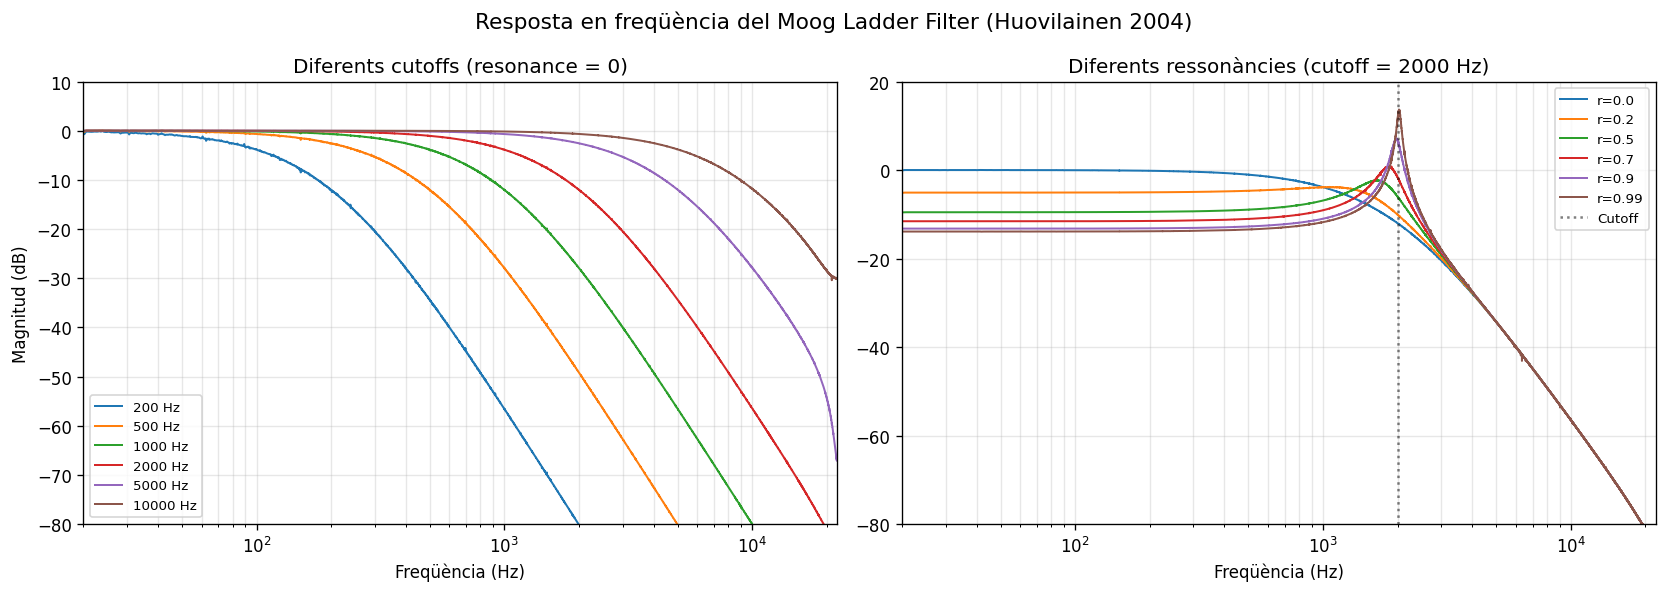

In [18]:
SR = 44100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Esquerra: diferents cutoffs, ressonància fixa ---
ax = axes[0]
for cutoff in [200, 500, 1000, 2000, 5000, 10000]:
    filt = MoogLadderFilter(SR, cutoff=cutoff, resonance=0.0, oversample=2)
    x = white_noise(duration=2.0, amplitude=0.01, sr=SR)
    filt.reset()
    y = filt.process(x)
    freqs_x, mag_x = compute_spectrum(x, SR)
    freqs_y, mag_y = compute_spectrum(y, SR)
    resp = mag_y - mag_x
    ax.semilogx(freqs_y[1:], resp[1:], label=f'{cutoff} Hz', lw=1.2)
ax.set_title('Diferents cutoffs (resonance = 0)')
ax.set_xlabel('Freqüència (Hz)')
ax.set_ylabel('Magnitud (dB)')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([20, SR/2])
ax.set_ylim([-80, 10])

# --- Dreta: diferents ressonàncies, cutoff fix ---
ax = axes[1]
cutoff = 2000
for res in [0.0, 0.2, 0.5, 0.7, 0.9, 0.99]:
    filt = MoogLadderFilter(SR, cutoff=cutoff, resonance=res, oversample=2)
    x = white_noise(duration=2.0, amplitude=0.01, sr=SR)
    filt.reset()
    y = filt.process(x)
    freqs_x, mag_x = compute_spectrum(x, SR)
    freqs_y, mag_y = compute_spectrum(y, SR)
    resp = mag_y - mag_x
    ax.semilogx(freqs_y[1:], resp[1:], label=f'r={res}', lw=1.2)
ax.axvline(cutoff, color='k', linestyle=':', alpha=0.5, label=f'Cutoff')
ax.set_title(f'Diferents ressonàncies (cutoff = {cutoff} Hz)')
ax.set_xlabel('Freqüència (Hz)')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([20, SR/2])
ax.set_ylim([-80, 20])

plt.suptitle('Resposta en freqüència del Moog Ladder Filter (Huovilainen 2004)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Comparació: amb i sense retard de mitja unitat

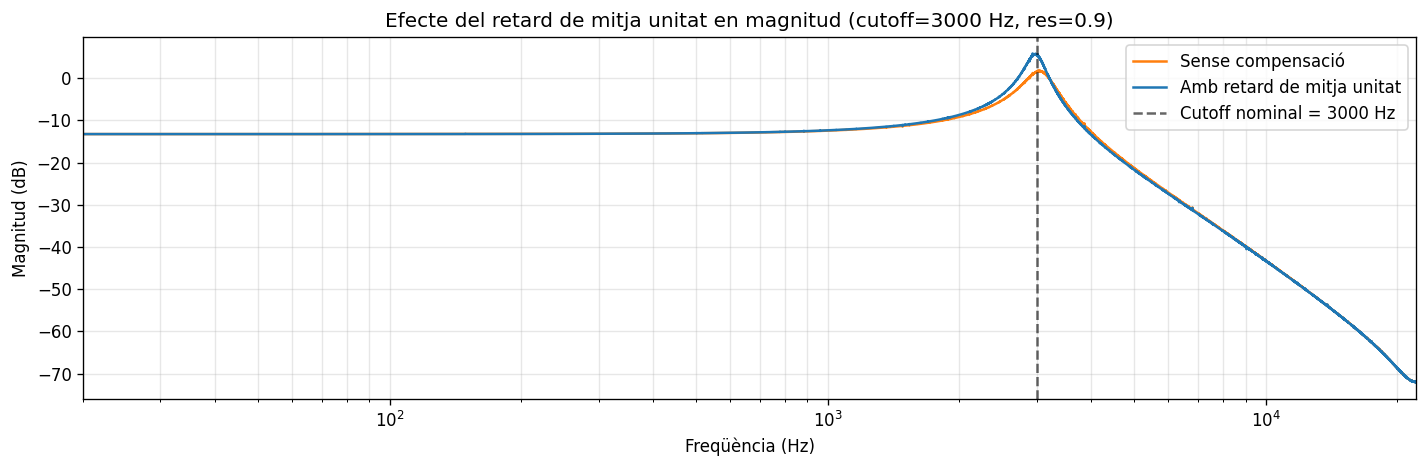

In [51]:
cutoff = 3000
res    = 0.9
x_test = white_noise(duration=2.0, amplitude=0.01, sr=SR)

fig, ax = plt.subplots(figsize=(12, 4))

for half_delay, label, color in [(False, 'Sense compensació', 'C1'),
                                  (True,  'Amb retard de mitja unitat', 'C0')]:
    filt = MoogLadderFilter(SR, cutoff=cutoff, resonance=res,
                            oversample=2, half_delay=half_delay)
    filt.reset()
    y = filt.process(x_test)
    freqs_x, mag_x = compute_spectrum(x_test, SR)
    freqs_y, mag_y = compute_spectrum(y, SR)
    resp = mag_y - mag_x
    ax.semilogx(freqs_y[1:], resp[1:], label=label, color=color, lw=1.5)

ax.axvline(cutoff, color='k', linestyle='--', alpha=0.6, label=f'Cutoff nominal = {cutoff} Hz')
ax.set_title(f'Efecte del retard de mitja unitat en magnitud (cutoff={cutoff} Hz, res={res})')
ax.set_xlabel('Freqüència (Hz)')
ax.set_ylabel('Magnitud (dB)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([20, SR/2])
plt.tight_layout()
plt.show()

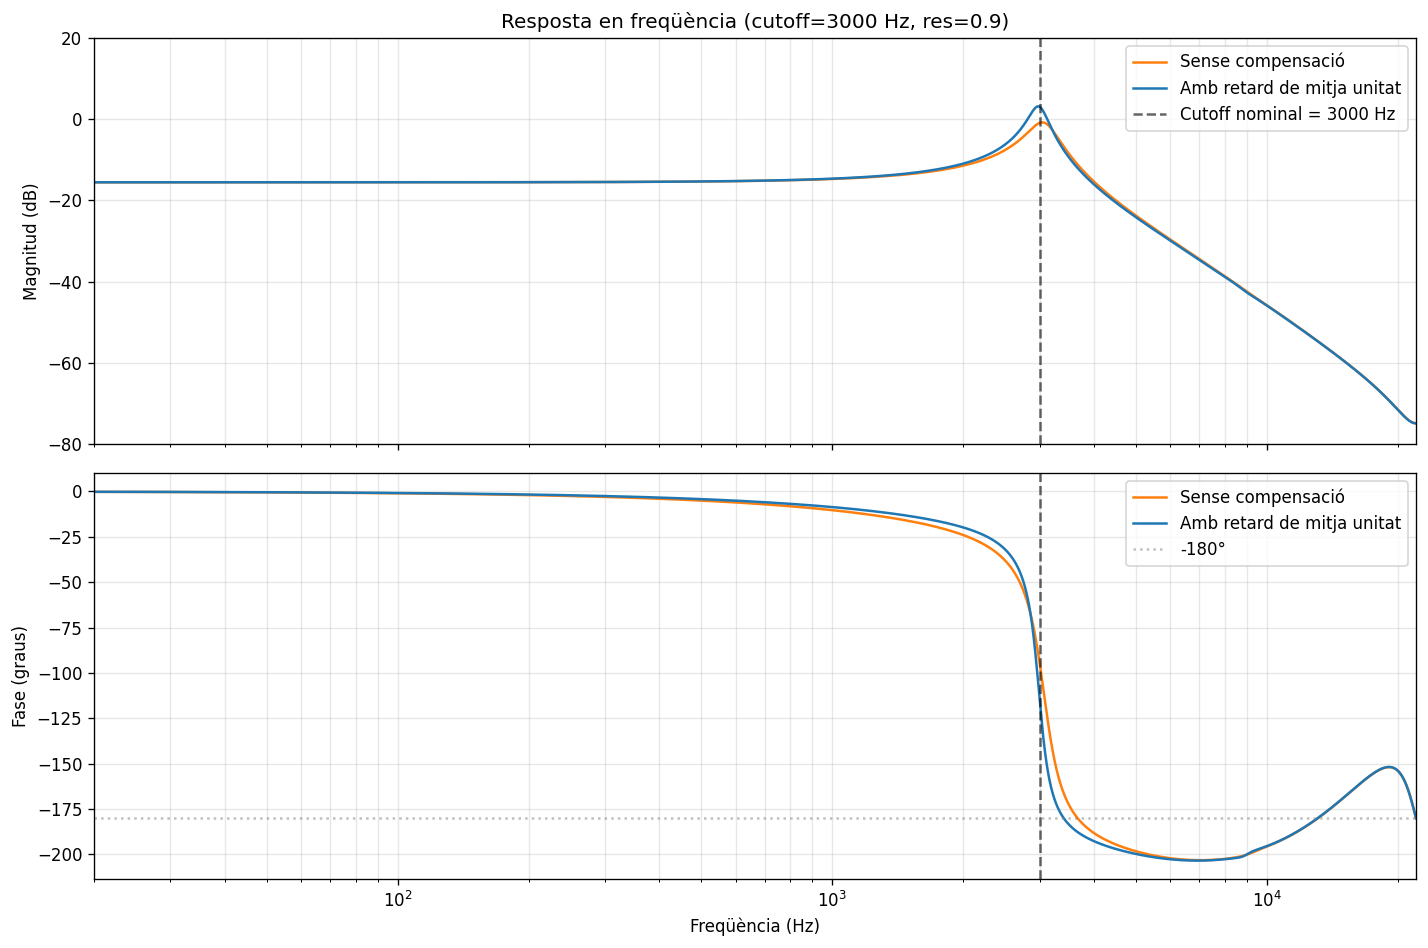

In [52]:
cutoff = 3000
res    = 0.9

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for half_delay, label, color in [(False, 'Sense compensació', 'C1'),
                                  (True,  'Amb retard de mitja unitat', 'C0')]:
    # Resposta a l'impuls: entrada és directament un impuls unitari
    x_imp = impulse(duration=0.5, amplitude=1.0, sr=SR)
    filt = MoogLadderFilter(SR, cutoff=cutoff, resonance=res,
                            oversample=2, half_delay=half_delay)
    filt.reset()
    h = filt.process(x_imp)   # h és la resposta a l'impuls

    n_fft = next_power_of_2(len(h))
    H = np.fft.rfft(h, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1.0/SR)

    mag_db = 20 * np.log10(np.abs(H) + 1e-12)
    phase  = np.unwrap(np.angle(H)) * (180 / np.pi)

    axes[0].semilogx(freqs[1:], mag_db[1:], label=label, color=color, lw=1.5)
    axes[1].semilogx(freqs[1:], phase[1:],  label=label, color=color, lw=1.5)

axes[0].axvline(cutoff, color='k', linestyle='--', alpha=0.6,
                label=f'Cutoff nominal = {cutoff} Hz')
axes[0].set_ylabel('Magnitud (dB)')
axes[0].set_title(f'Resposta en freqüència (cutoff={cutoff} Hz, res={res})')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)
axes[0].set_ylim([-80, 20])

axes[1].axvline(cutoff, color='k', linestyle='--', alpha=0.6)
axes[1].axhline(-180, color='gray', linestyle=':', alpha=0.5, label='-180°')
axes[1].set_ylabel('Fase (graus)')
axes[1].set_xlabel('Freqüència (Hz)')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

axes[0].set_xlim([20, SR/2])
plt.tight_layout()
plt.show()

## 6. Prova amb diferents senyals d'entrada

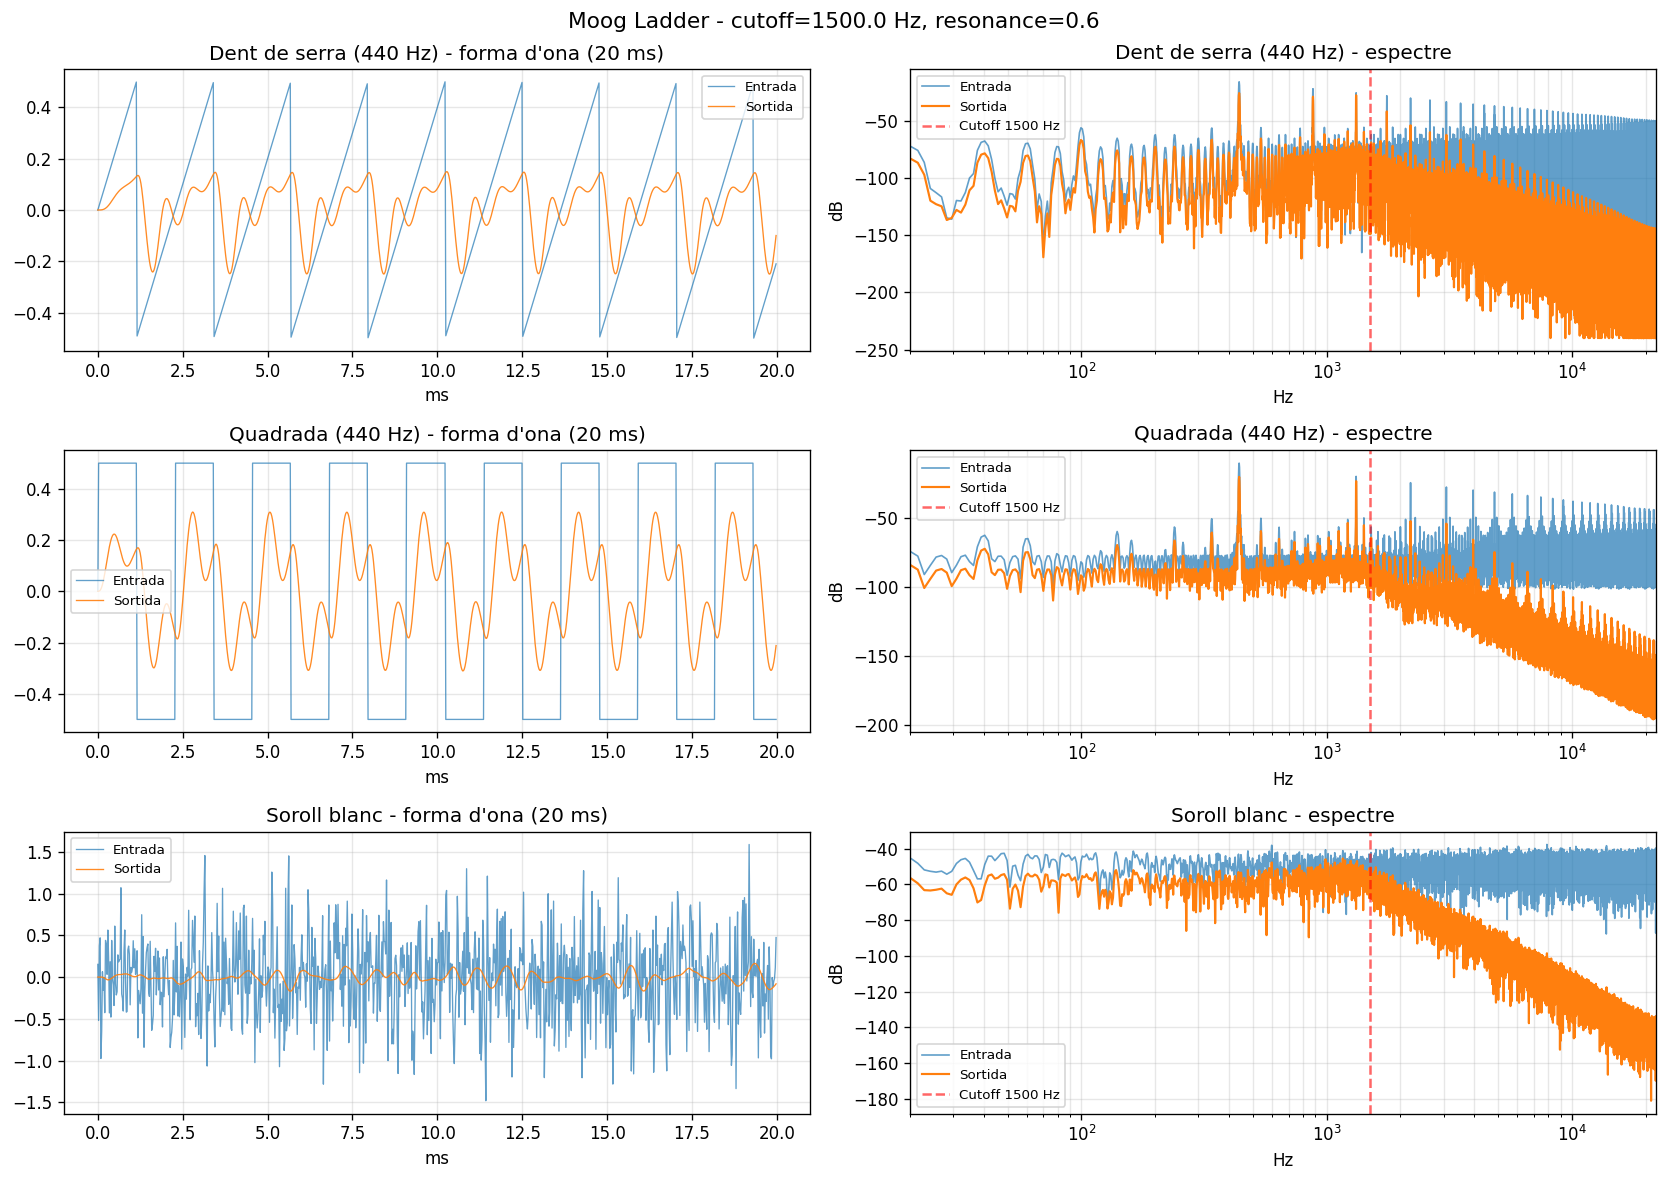

In [20]:
CUTOFF    = 1500.0
RESONANCE = 0.6
DURATION  = 0.5    # segons
AMPLITUDE = 0.5

signals = {
    'Dent de serra (440 Hz)': sawtooth(440, DURATION, AMPLITUDE, SR),
    'Quadrada (440 Hz)':         square(440,   DURATION, AMPLITUDE, SR),
    'Soroll blanc':              white_noise(DURATION,   AMPLITUDE, SR),
}

fig, axes = plt.subplots(len(signals), 2, figsize=(14, 10))

for row, (name, x) in enumerate(signals.items()):
    filt = MoogLadderFilter(SR, cutoff=CUTOFF, resonance=RESONANCE, oversample=2)
    filt.reset()
    y = filt.process(x)

    freqs_x, mag_x = compute_spectrum(x, SR)
    freqs_y, mag_y = compute_spectrum(y, SR)

    # Forma de onda
    n_show = int(SR * 0.02)
    t_ms   = np.arange(n_show) / SR * 1000
    axes[row, 0].plot(t_ms, x[:n_show], lw=0.8, label='Entrada', alpha=0.7)
    axes[row, 0].plot(t_ms, y[:n_show], lw=0.8, label='Sortida', alpha=0.9)
    axes[row, 0].set_title(f"{name} - forma d'ona (20 ms)")
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].set_xlabel('ms')
    axes[row, 0].grid(alpha=0.3)

    # Espectro
    axes[row, 1].semilogx(freqs_x[1:], mag_x[1:], label='Entrada', alpha=0.7, lw=1)
    axes[row, 1].semilogx(freqs_y[1:], mag_y[1:], label='Sortida', lw=1.3)
    axes[row, 1].axvline(CUTOFF, color='r', linestyle='--', alpha=0.6,
                         label=f'Cutoff {CUTOFF:.0f} Hz')
    axes[row, 1].set_title(f'{name} - espectre')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].set_xlabel('Hz')
    axes[row, 1].set_ylabel('dB')
    axes[row, 1].grid(True, which='both', alpha=0.3)
    axes[row, 1].set_xlim([20, SR/2])

plt.suptitle(f'Moog Ladder - cutoff={CUTOFF} Hz, resonance={RESONANCE}', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Efecte de la no linealitat: amplitud d'entrada vs distorsió

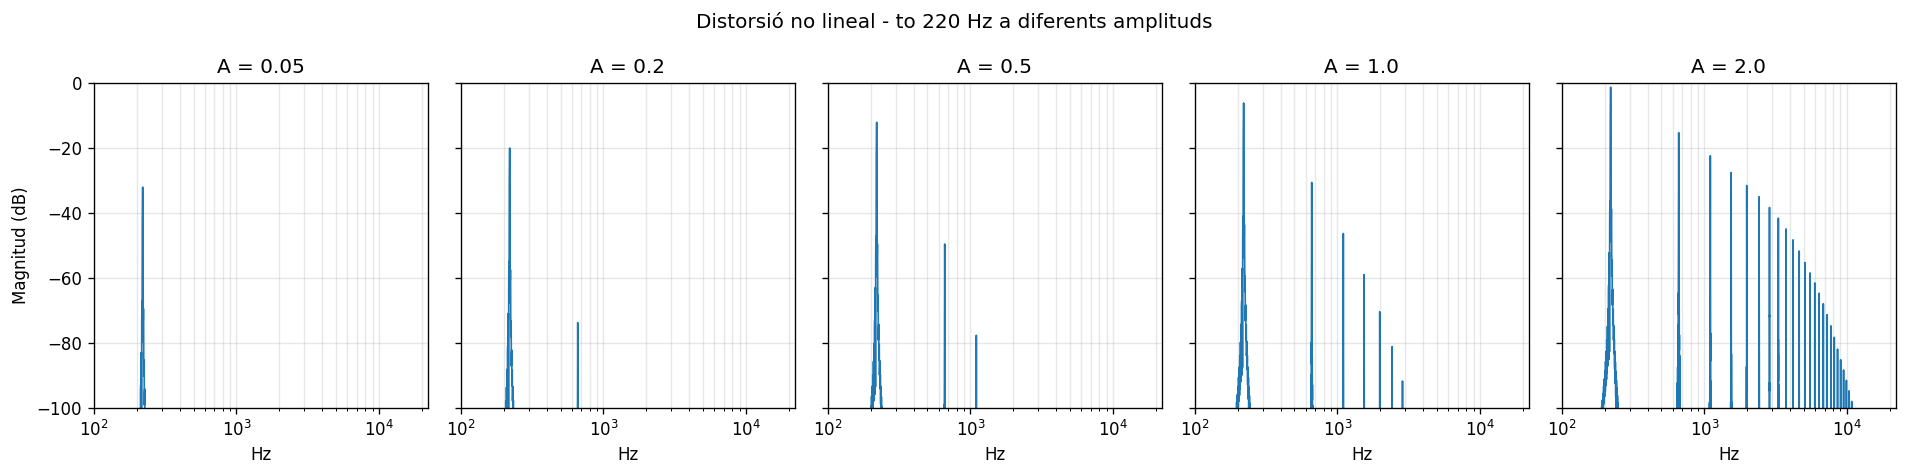

In [21]:
"""
Amb més amplitud d'entrada, el tanh satura i es generen harmònics.
Aquí ho visualitzem comparant l'espectre de sortida per a diferents
amplituds d'un to pur.
"""
FREQ   = 220    # Hz - to de prova
CUTOFF_NL = 5000  # Hz - cutoff alt per veure els harmònics generats

amplitudes = [0.05, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(amplitudes), figsize=(16, 4), sharey=True)

for ax, amp in zip(axes, amplitudes):
    x = sine(FREQ, duration=1.0, amplitude=amp, sr=SR)
    filt = MoogLadderFilter(SR, cutoff=CUTOFF_NL, resonance=0.0, oversample=2)
    filt.reset()
    y = filt.process(x)
    freqs_y, mag_y = compute_spectrum(y, SR)
    ax.semilogx(freqs_y[1:], mag_y[1:], lw=1)
    ax.set_title(f'A = {amp}')
    ax.set_xlabel('Hz')
    ax.set_xlim([100, SR/2])
    ax.set_ylim([-100, 0])
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('Magnitud (dB)')
fig.suptitle(f'Distorsió no lineal - to {FREQ} Hz a diferents amplituds', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Sweeps de paràmetres en temps real (modulació)

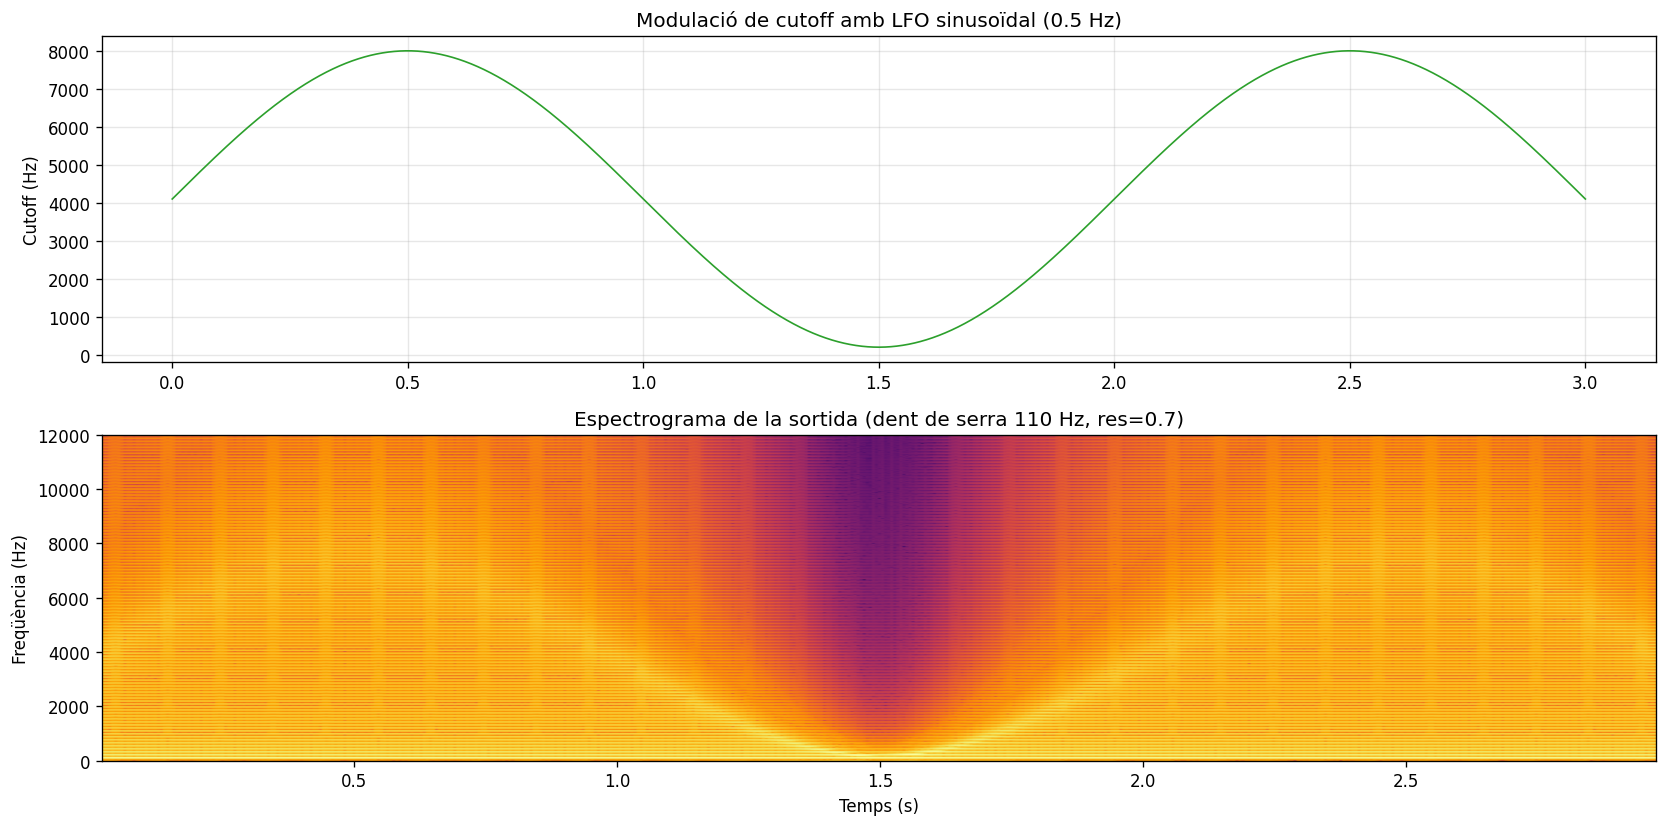

In [22]:
class MoogLadderFilterModulable(MoogLadderFilter):
    """
    Versió que permet canviar cutoff i resonance mostra a mostra
    per simular modulació (LFO, envolvent)
    """

    def process_modulated(self, x_in, cutoff_env, resonance_env):
        """
        x_in, cutoff_env i resonance_env han de tenir la mateixa longitud.
        cutoff_env:    array amb la freqüència de tall en Hz per mostra.
        resonance_env: array amb la ressonància [0,1] per mostra.
        """
        n  = len(x_in)
        os = self.oversample
        x_up   = np.repeat(x_in,        os)
        c_up   = np.repeat(cutoff_env,   os)
        r_up   = np.repeat(resonance_env, os)

        y_up = np.empty(len(x_up))
        for i in range(len(x_up)):
            self.set_cutoff(c_up[i])
            self.set_resonance(r_up[i])
            y_up[i] = self._process_sample(x_up[i])

        return y_up[os-1::os]


# --- Prova: sweep de cutoff amb LFO sinusoidal ---
DURATION_MOD = 3.0  # s
t = np.linspace(0, DURATION_MOD, int(SR * DURATION_MOD), endpoint=False)

x_saw = sawtooth(110, DURATION_MOD, amplitude=0.4, sr=SR)

# LFO: cutoff oscil·la entre 200 Hz i 8000 Hz a 0.5 Hz
lfo_rate   = 0.5   # Hz
cutoff_min = 200.0
cutoff_max = 8000.0
cutoff_sweep = cutoff_min + (cutoff_max - cutoff_min) * 0.5 * (1 + np.sin(2*np.pi*lfo_rate*t))

res_sweep = np.full_like(t, 0.7)

filt_mod = MoogLadderFilterModulable(SR, oversample=2)
filt_mod.reset()
y_mod = filt_mod.process_modulated(x_saw, cutoff_sweep, res_sweep)

# Plot: espectrograma
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(t, cutoff_sweep, lw=1, color='C2')
axes[0].set_ylabel('Cutoff (Hz)')
axes[0].set_title('Modulació de cutoff amb LFO sinusoïdal (0.5 Hz)')
axes[0].grid(alpha=0.3)

axes[1].specgram(y_mod, NFFT=2048, Fs=SR, noverlap=1792, cmap='inferno')
axes[1].set_ylabel('Freqüència (Hz)')
axes[1].set_xlabel('Temps (s)')
axes[1].set_title('Espectrograma de la sortida (dent de serra 110 Hz, res=0.7)')
axes[1].set_ylim([0, 12000])

plt.tight_layout()
plt.show()

## 9. Auto-oscil·lació (resonance ≈ 1)

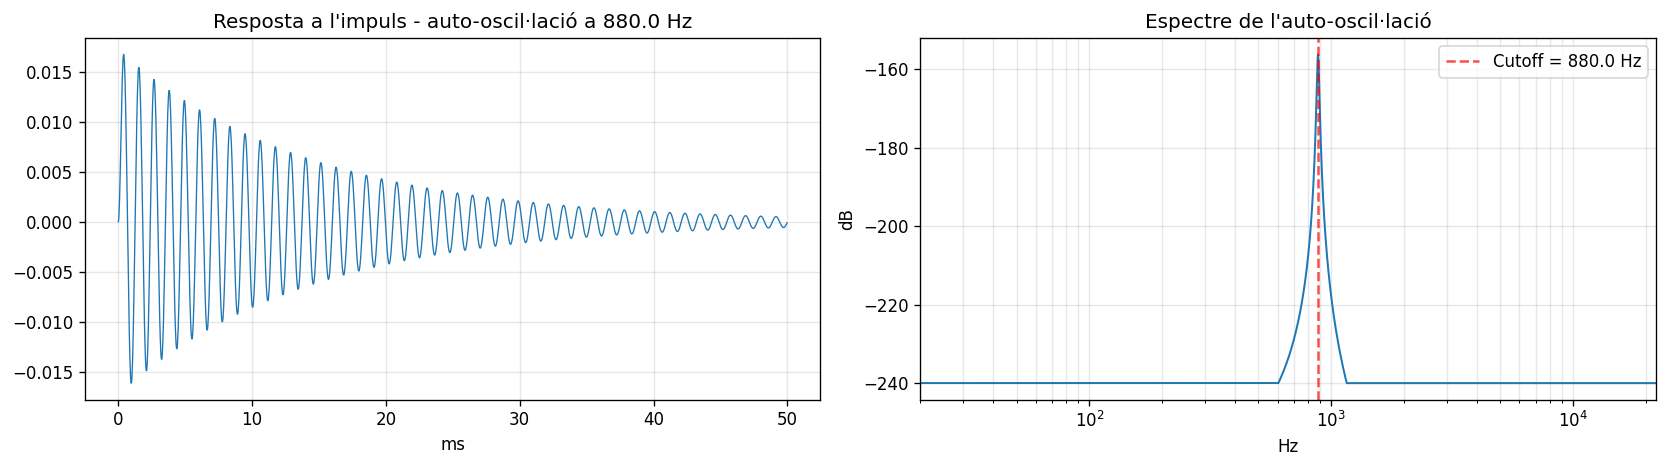

In [ ]:
"""
Amb resonance molt propera a 1, el filtre oscil·la.
Es pot excitar amb un impuls breu i després silenci.
"""
CUTOFF_OSC = 880.0   # Hz
RES_OSC    = 0.98
DURATION_OSC = 0.3   # s

x_imp = impulse(duration=DURATION_OSC, amplitude=1.0, sr=SR)

filt_osc = MoogLadderFilter(SR, cutoff=CUTOFF_OSC, resonance=RES_OSC, oversample=2)
filt_osc.reset()
y_osc = filt_osc.process(x_imp)

freqs_osc, mag_osc = compute_spectrum(y_osc, SR)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

n_show = int(SR * 0.05)
t_ms = np.arange(n_show) / SR * 1000
axes[0].plot(t_ms, y_osc[:n_show], lw=0.8)
axes[0].set_title(f"Resposta a l'impuls - auto-oscil·lació a {CUTOFF_OSC} Hz")
axes[0].set_xlabel('ms')
axes[0].grid(alpha=0.3)

axes[1].semilogx(freqs_osc[1:], mag_osc[1:], lw=1.2)
axes[1].axvline(CUTOFF_OSC, color='r', linestyle='--', alpha=0.7,
                label=f'Cutoff = {CUTOFF_OSC} Hz')
axes[1].set_title("Espectre de l'auto-oscil·lació")
axes[1].set_xlabel('Hz')
axes[1].set_ylabel('dB')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)
axes[1].set_xlim([20, SR/2])

plt.tight_layout()
plt.show()

## 10. Exportar audio a WAV

In [24]:
def save_wav(filename, signal, sr=44100, normalize=True):
    """Guarda un array float com arxiu WAV 16-bit."""
    s = signal.copy()
    if normalize:
        peak = np.max(np.abs(s))
        if peak > 0:
            s = s / peak * 0.9
    s_int = (s * 32767).astype(np.int16)
    wavfile.write(filename, sr, s_int)
    print(f'Guardado: {filename}')

def play_audio(signal, sr=44100, normalize=True):
    s = signal.copy()
    if normalize:
        peak = np.max(np.abs(s))
        if peak > 0:
            s = s / peak * 0.9
    display(Audio(s, rate=sr))

In [25]:
# --- Exemple d'exportació ---
x_export = sawtooth(110, duration=3.0, amplitude=0.5, sr=SR)
t_export = np.linspace(0, 3.0, len(x_export), endpoint=False)

# Envolvent ADSR simple per al cutoff
cutoff_env_export = 300 + 6000 * np.exp(-t_export * 2)

filt_export = MoogLadderFilterModulable(SR, resonance=0.7, oversample=2)
filt_export.reset()
y_export = filt_export.process_modulated(
    x_export,
    cutoff_env_export,
    np.full_like(t_export, 0.7)
)
save_wav('saw_export.wav', x_export, sr=SR)
save_wav('moog_export.wav', y_export, sr=SR)
play_audio(x_export, sr=SR)
play_audio(y_export, sr=SR)

Guardado: saw_export.wav
Guardado: moog_export.wav


## 11. Experimenteu amb els paràmetres

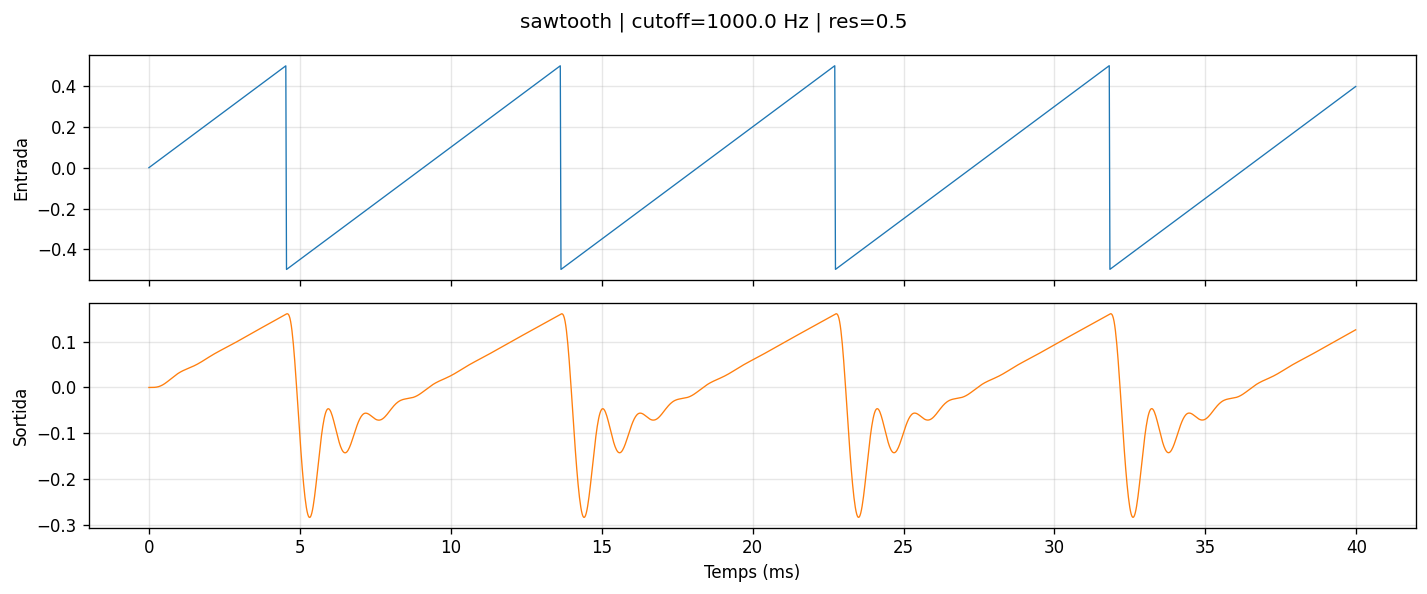

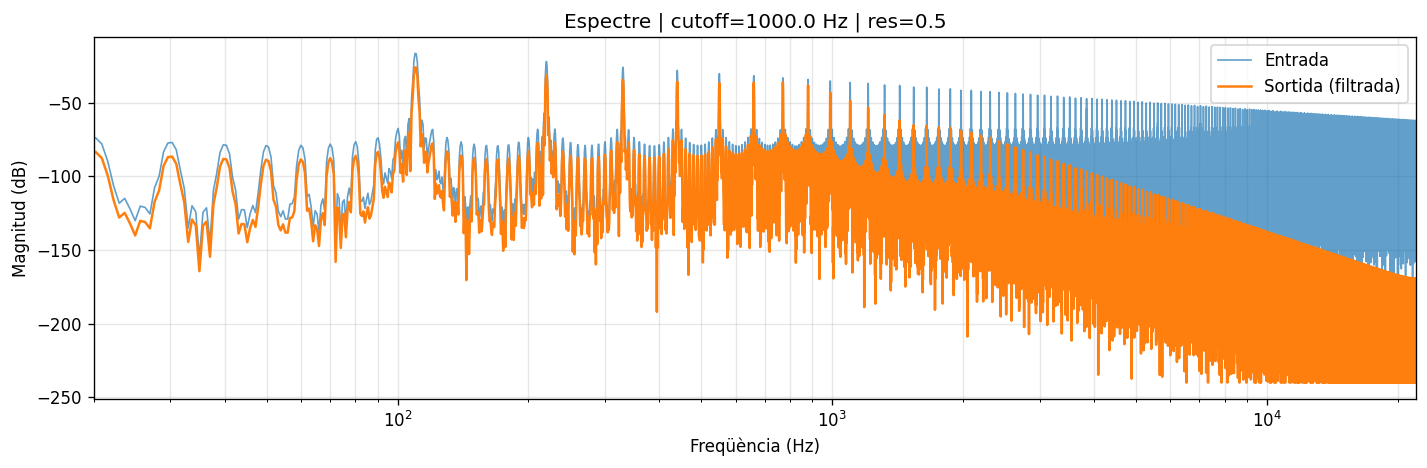

In [26]:
# PARÀMETRES

SIGNAL_TYPE = 'sawtooth'   # 'sine' | 'sawtooth' | 'square' | 'noise' | 'impulse'
FREQ_HZ     = 110          # freqüència de l'oscil·lador (no aplica per a 'noise'/'impulse')
AMPLITUDE   = 0.5          # amplitud d'entrada (proveu valors > 1 per a saturació)
DURATION_S  = 1.0          # duració en segons

CUTOFF_HZ   = 1000.0       # freqüència de tall (Hz)
RESONANCE   = 0.5          # ressonància [0,1]
OVERSAMPLE  = 2            # factor de sobremostreig (1, 2 o 4)
HALF_DELAY  = True         # retard en mitja unitat

# GENERACIÓ DE SENYAL
gen = GENERATORS[SIGNAL_TYPE]
if SIGNAL_TYPE in ('sine', 'sawtooth', 'square'):
    x_sb = gen(FREQ_HZ, DURATION_S, AMPLITUDE, SR)
elif SIGNAL_TYPE == 'noise':
    x_sb = gen(DURATION_S, AMPLITUDE, SR)
else:  # impulse
    x_sb = gen(DURATION_S, AMPLITUDE, SR)

# FILTRAT
filt_sb = MoogLadderFilter(SR, cutoff=CUTOFF_HZ, resonance=RESONANCE,
                           oversample=OVERSAMPLE, half_delay=HALF_DELAY)
filt_sb.reset()
y_sb = filt_sb.process(x_sb)

# PLOTS
plot_waveform(x_sb, y_sb, SR, duration_ms=40,
              title=f'{SIGNAL_TYPE} | cutoff={CUTOFF_HZ} Hz | res={RESONANCE}')
plot_io_spectrum(x_sb, y_sb, SR,
                 title=f'Espectre | cutoff={CUTOFF_HZ} Hz | res={RESONANCE}')

# REPRODUIR ÀUDIO
play_audio(y_sb, sr=44100)